In [6]:
import sys

sys.path.insert(0, '..')

from utils.preprocessing import (
    load_and_preprocess_data,
    FEATURES,
)
from utils.evaluation import (
    load_and_evaluate_rf_model,
    load_and_evaluate_cnnlstm_model,
)
import pandas as pd

## Preprocess data

In [2]:
df_cicids2017_wednesday = load_and_preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_cicids2017_friday = load_and_preprocess_data("../data/CICIDS2017/friday_labeled.tsv")
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

df_cicids2017 = pd.concat([df_cicids2017_wednesday, df_cicids2017_friday], ignore_index=True)
dataframes = [df_cicids2017, df_ciciot2023]

In [3]:
label_column = "label"

df_cicids2017 = df_cicids2017[df_cicids2017[label_column].isin(["DOS_HTTP_FLOOD", "PORTSCAN"] + ["BENIGN"])]
df_ciciot2023 = df_ciciot2023[df_ciciot2023[label_column].isin(["DOS_HTTP_FLOOD", "PORTSCAN"] + ["BENIGN"])]

X_cicids = df_cicids2017[FEATURES]
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023[FEATURES]
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (933833, 19)
CICIoT test shape: (2067377, 19)


## Load Models and evaluate

Evaluation for CICIDS2017-trained RF on CICIoT2023:

=== CICIDS2017-trained RF on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1795    0.9954    0.3041    342255
DOS_HTTP_FLOOD     0.9999    0.0233    0.0455   1508589
      PORTSCAN     0.5272    0.3259    0.4028    216533

      accuracy                         0.2159   2067377
     macro avg     0.5689    0.4482    0.2508   2067377
  weighted avg     0.8145    0.2159    0.1257   2067377


=== Per-Label Accuracy ===

BENIGN: 0.9954
DOS_HTTP_FLOOD: 0.0233
PORTSCAN: 0.3259


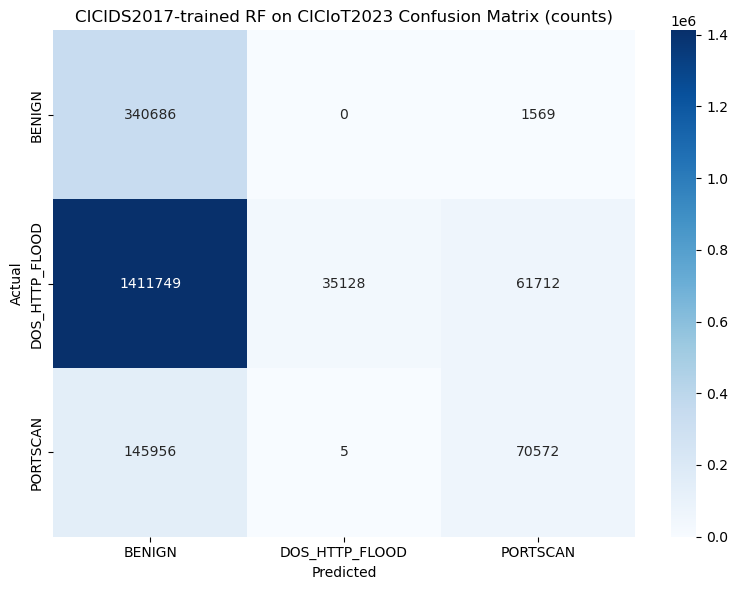

In [8]:
# Test CICIDS2017-trained RF model on CICIoT2023
load_and_evaluate_rf_model(
    joblib_path="models/random_forest_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained RF on CICIoT2023"
)

Evaluation for CICIoT2023-trained RF on CICIDS2017:

=== CICIoT2023-trained RF on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9945    0.8085    0.8919    625030
DOS_HTTP_FLOOD     0.3719    0.4857    0.4212    154769
      PORTSCAN     0.3302    0.4793    0.3910    154034

      accuracy                         0.7007    933833
     macro avg     0.5655    0.5912    0.5681    933833
  weighted avg     0.7817    0.7007    0.7313    933833


=== Per-Label Accuracy ===

BENIGN: 0.8085
DOS_HTTP_FLOOD: 0.4857
PORTSCAN: 0.4793


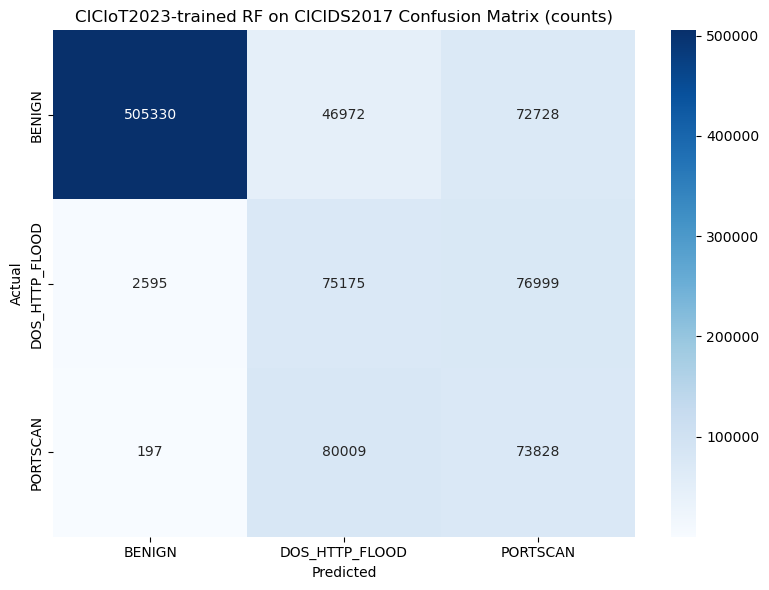

In [7]:
# Test CICIoT2023-trained RF model on CICIDS2017
load_and_evaluate_rf_model(
    joblib_path="models/random_forest_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained RF on CICIDS2017"
)

Evaluation for CICIoT2023-trained CNN-LSTM on CICIDS2017:

=== CICIoT2023-trained CNN-LSTM on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9066    0.8866    0.8965    625030
DOS_HTTP_FLOOD     0.6474    0.6335    0.6404    154769
      PORTSCAN     0.8352    0.9283    0.8793    154034

      accuracy                         0.8515    933833
     macro avg     0.7964    0.8161    0.8054    933833
  weighted avg     0.8519    0.8515    0.8512    933833


=== Per-Label Accuracy ===

BENIGN: 0.8866
DOS_HTTP_FLOOD: 0.6335
PORTSCAN: 0.9283


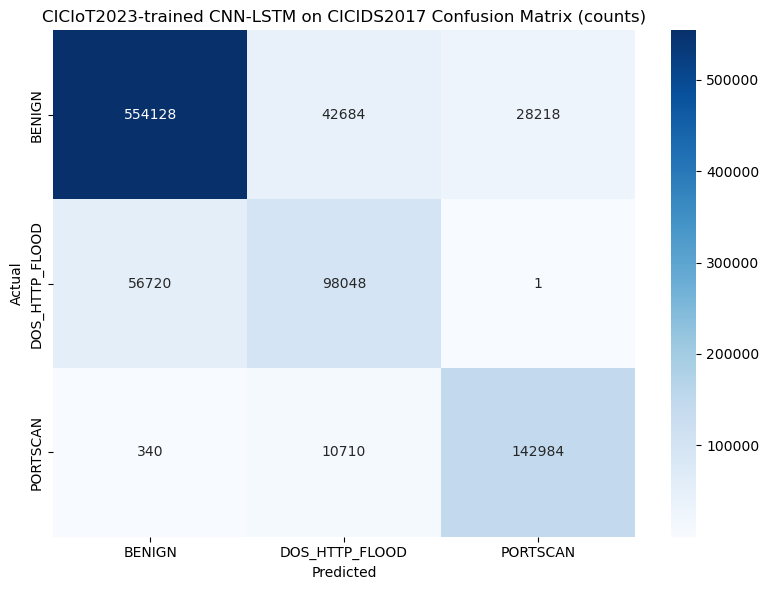

In [4]:
# Test CICIoT2023-trained CNN-LSTM model on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNN-LSTM on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNN-LSTM on CICIoT2023:

=== CICIDS2017-trained CNN-LSTM on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1727    0.9336    0.2915    342255
DOS_HTTP_FLOOD     0.8727    0.0488    0.0923   1508589
      PORTSCAN     0.5078    0.3123    0.3867    216533

      accuracy                         0.2228   2067377
     macro avg     0.5178    0.4315    0.2569   2067377
  weighted avg     0.7186    0.2228    0.1562   2067377


=== Per-Label Accuracy ===

BENIGN: 0.9336
DOS_HTTP_FLOOD: 0.0488
PORTSCAN: 0.3123


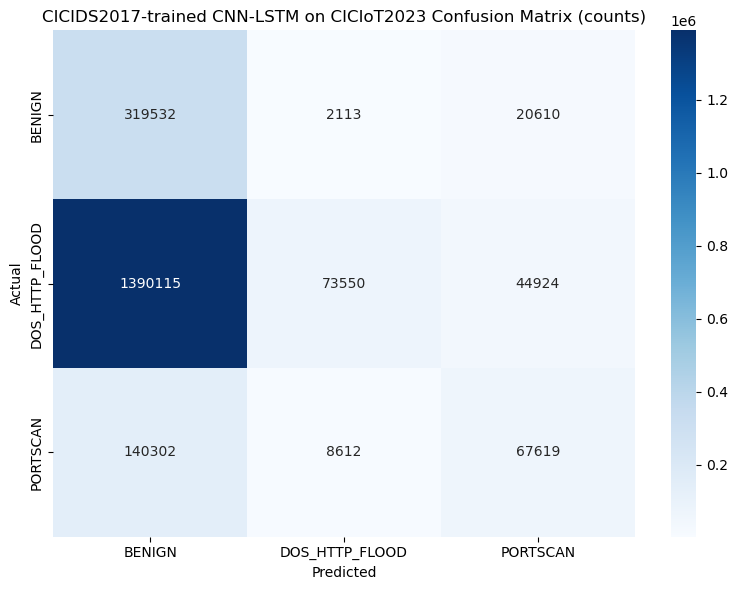

In [5]:
# Test CICIDS2017-trained CNN-LSTM model on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNN-LSTM on CICIoT2023"
)